🧠 TRAINING GP ON SUPER-DATASET FOR PARTIAL DEPENDENCE 🧠
Device: cuda | Total Data Points: 3000
Epoch  500/2000 - Joint Loss: 0.0273
Epoch 1000/2000 - Joint Loss: -0.0002
Epoch 1500/2000 - Joint Loss: -0.0089
Epoch 2000/2000 - Joint Loss: -0.0061

📊 GENERATING THESIS-GRADE PARTIAL DEPENDENCE PLOTS 📊
✅ Master Plot successfully saved to: thesis_final_partial_dependence.png


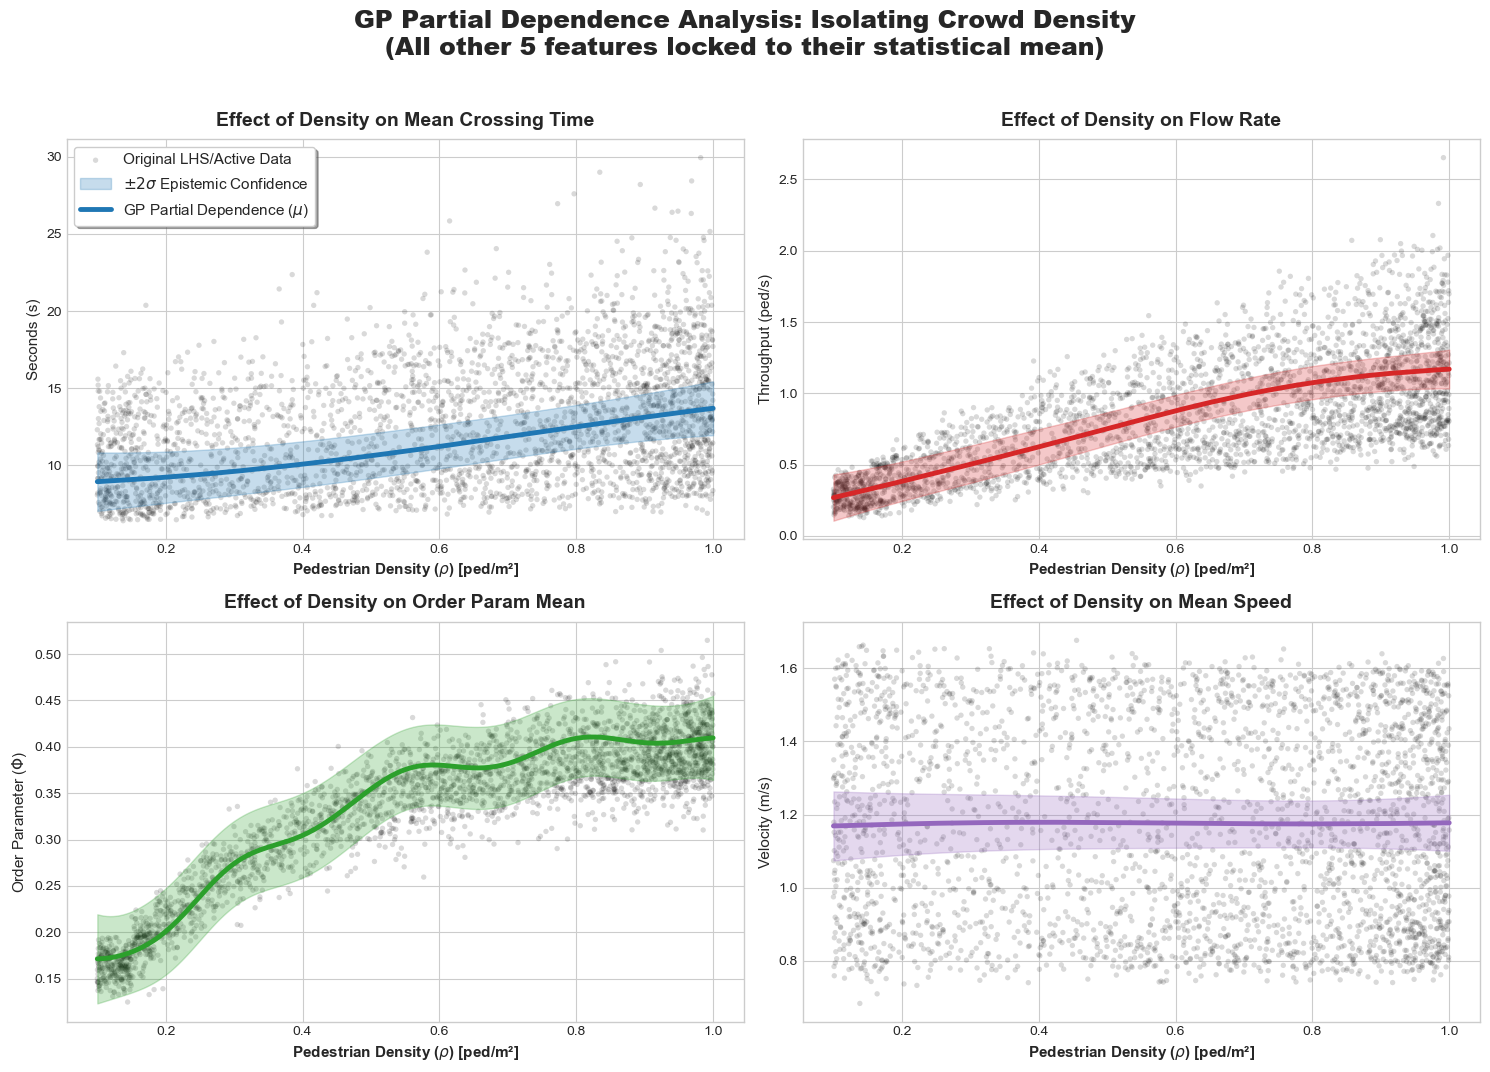

In [1]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")
# Use a highly professional academic plot style
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# 1. GPYTORCH KERNEL & MODEL ARCHITECTURE
# ==========================================
class HeteroscedasticTaskGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(HeteroscedasticTaskGP, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=6)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ==========================================
# 2. FAST TRAINING PIPELINE (3000 Points)
# ==========================================
def train_surrogate_for_pdp(data_path):
    print("="*70)
    print("🧠 TRAINING GP ON SUPER-DATASET FOR PARTIAL DEPENDENCE 🧠")
    print("="*70)
    
    data = np.load(data_path)
    X_raw, Y_raw, Y_std_raw = data['X'], data['Y'], data['Y_std']
    param_names = data['param_names']
    output_names = data['output_names']
    num_tasks = Y_raw.shape[1]
    
    # Clean NaNs
    valid_mask = ~np.isnan(Y_raw).any(axis=1)
    X_clean, Y_clean, Y_std_clean = X_raw[valid_mask], Y_raw[valid_mask], Y_std_raw[valid_mask]

    # Scaling
    scaler_X = StandardScaler()
    X_scaled = scaler_X.fit_transform(X_clean)
    
    scaler_Y = StandardScaler()
    Y_scaled = scaler_Y.fit_transform(Y_clean)
    Y_std_scaled = Y_std_clean / scaler_Y.scale_
    Y_var_scaled = Y_std_scaled ** 2 

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device: {device} | Total Data Points: {len(X_clean)}")
    
    train_x_t = torch.FloatTensor(X_scaled).to(device)
    
    models, likelihoods = [], []
    for i in range(num_tasks):
        train_y_t = torch.FloatTensor(Y_scaled[:, i]).to(device)
        train_noise_t = torch.FloatTensor(Y_var_scaled[:, i]).to(device)
        
        likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(
            noise=train_noise_t, learn_additional_noise=False
        ).to(device)
        model = HeteroscedasticTaskGP(train_x_t, train_y_t, likelihood).to(device)
        
        models.append(model)
        likelihoods.append(likelihood)

    model_list = gpytorch.models.IndependentModelList(*models)
    likelihood_list = gpytorch.likelihoods.LikelihoodList(*likelihoods)

    model_list.train()
    likelihood_list.train()
    
    optimizer = torch.optim.Adam(model_list.parameters(), lr=0.1)
    mll = gpytorch.mlls.SumMarginalLogLikelihood(likelihood_list, model_list)
    
    epochs = 2000 # Enough for convergence
    for i in range(epochs):
        optimizer.zero_grad()
        output = model_list(*[train_x_t for _ in range(num_tasks)])
        loss = -mll(output, [torch.FloatTensor(Y_scaled[:, t]).to(device) for t in range(num_tasks)])
        loss.backward()
        optimizer.step()
        if (i+1) % 500 == 0:
            print(f"Epoch {i+1:>4}/{epochs} - Joint Loss: {loss.item():.4f}")

    return model_list, scaler_X, scaler_Y, X_clean, Y_clean, param_names, output_names, device

# ==========================================
# 3. THE MATHEMATICAL PARTIAL DEPENDENCE GENERATOR
# ==========================================
def generate_partial_dependence(model_list, scaler_X, scaler_Y, X_clean, Y_clean, param_names, output_names, device):
    print("\n" + "="*70)
    print("📊 GENERATING THESIS-GRADE PARTIAL DEPENDENCE PLOTS 📊")
    print("="*70)

    num_tasks = len(output_names)
    density_idx = list(param_names).index("density")
    n_sweep = 200 # Super high resolution curve

    # ---------------------------------------------------------
    # HOW WE FIX THE OTHER FEATURES
    # We create a base array where every single row is exactly the same 
    # (the statistical MEAN of all simulations). 
    # ---------------------------------------------------------
    fixed_baselines = np.mean(X_clean, axis=0)
    X_sweep = np.tile(fixed_baselines, (n_sweep, 1))

    # [OPTIONAL ADVANCED TWEAK]: You can override the mean here!
    # Example: If you want to see what happens specifically when Flow Ratio is 0.5 (perfect counterflow)
    # flow_ratio_idx = list(param_names).index("flow_ratio")
    # X_sweep[:, flow_ratio_idx] = 0.50  

    # ---------------------------------------------------------
    # HOW WE VARY DENSITY
    # We replace only the 'density' column with values from 0.1 to 1.0
    # ---------------------------------------------------------
    den_sweep = np.linspace(np.min(X_clean[:, density_idx]), np.max(X_clean[:, density_idx]), n_sweep)
    X_sweep[:, density_idx] = den_sweep

    # Scale and move to PyTorch
    X_sweep_scaled_t = torch.FloatTensor(scaler_X.transform(X_sweep)).to(device)

    # GP Inference (Using model_list directly for pure Epistemic bounds)
    model_list.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        sweep_model_preds = model_list(*[X_sweep_scaled_t for _ in range(num_tasks)])

    # Setup the Canvas
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    axes = axes.flatten()
    
    # Beautiful Custom Colors for the 4 outputs
    plot_colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']

    for i in range(num_tasks):
        mean_scaled = sweep_model_preds[i].mean.cpu().numpy()
        std_scaled  = np.sqrt(sweep_model_preds[i].variance.cpu().numpy())

        # Inverse transform to real-world physics units
        mean_real = (mean_scaled * scaler_Y.scale_[i]) + scaler_Y.mean_[i]
        std_real  = std_scaled * scaler_Y.scale_[i] 

        ax = axes[i]
        
        # 1. Plot the raw background scatter (Black Dots)
        # This proves the GP isn't just making things up; the data exists.
        ax.scatter(X_clean[:, density_idx], Y_clean[:, i],
                   color='black', alpha=0.15, s=15, edgecolors='none', label='Original LHS/Active Data')
        
        # 2. Plot the Epistemic Uncertainty Band
        ax.fill_between(den_sweep,
                        mean_real - 2*std_real,
                        mean_real + 2*std_real,
                        color=plot_colors[i], alpha=0.25, label=r'$\pm 2\sigma$ Epistemic Confidence')
        
        # 3. Plot the Core Mathematical Prediction Line
        ax.plot(den_sweep, mean_real, color=plot_colors[i], lw=3.5, label='GP Partial Dependence ($\mu$)')

        # Formatting
        title_str = output_names[i].replace('_', ' ').title()
        ax.set_title(f"Effect of Density on {title_str}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel(r"Pedestrian Density ($\rho$) [ped/m²]", fontsize=11, fontweight='bold')
        
        if "Time" in title_str: ax.set_ylabel("Seconds (s)", fontsize=11)
        elif "Flow" in title_str: ax.set_ylabel("Throughput (ped/s)", fontsize=11)
        elif "Speed" in title_str: ax.set_ylabel("Velocity (m/s)", fontsize=11)
        elif "Order" in title_str: ax.set_ylabel("Order Parameter ($\Phi$)", fontsize=11)

        ax.tick_params(axis='both', which='major', labelsize=10)
        if i == 0:
            ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)

    plt.suptitle("GP Partial Dependence Analysis: Isolating Crowd Density\n(All other 5 features locked to their statistical mean)", 
                 fontsize=18, fontweight='black', y=0.97)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to fit the suptitle
    
    save_file = "thesis_final_partial_dependence.png"
    plt.savefig(save_file, dpi=400, bbox_inches='tight')
    print(f"✅ Master Plot successfully saved to: {save_file}")
    plt.show()

if __name__ == "__main__":
    # POINT THIS TO YOUR NEW 3000 POINT DATASET!
    DATA_PATH = r"D:\KIT\cafm_lhs_3000_active.npz"
    
    # Run the pipeline
    models, sX, sY, Xc, Yc, p_names, o_names, dev = train_surrogate_for_pdp(DATA_PATH)
    generate_partial_dependence(models, sX, sY, Xc, Yc, p_names, o_names, dev)

## GP on Density to all output (1 to 4)

🧠 TRAINING PURE 1D GP (DENSITY -> 4 OUTPUTS) 🧠
Training the 1D GPs...

Generating the 1D Uncertainty Plot...
✅ Plot successfully saved to: marginal_1d_gp_plot.png


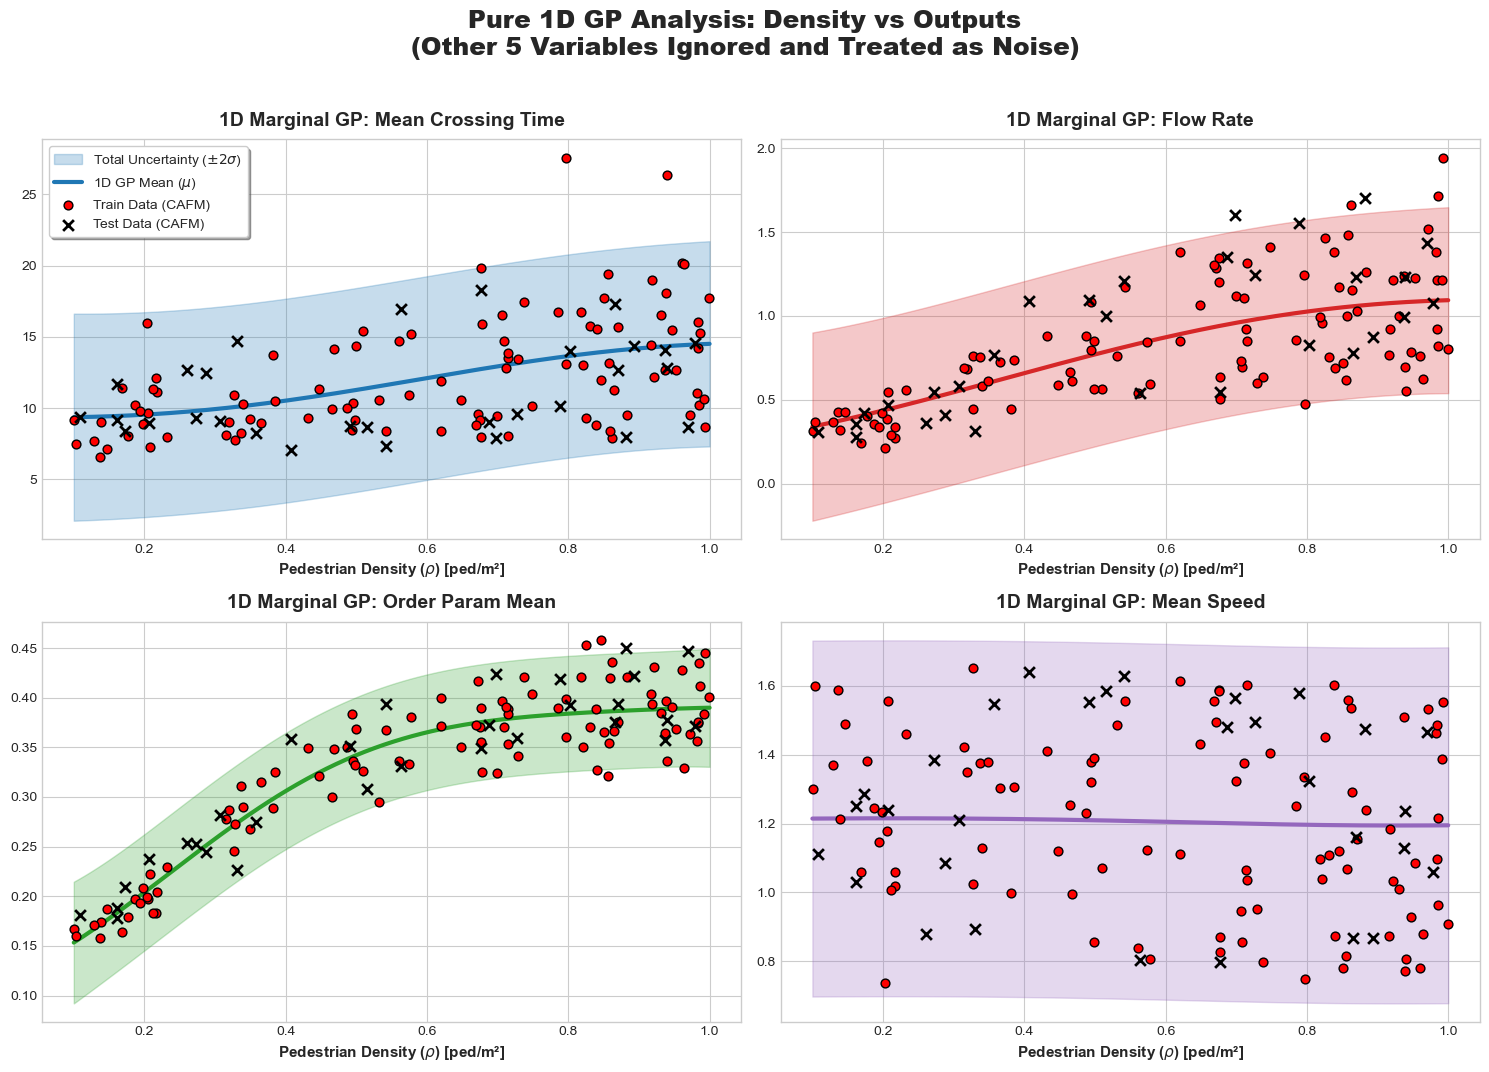

In [2]:
import numpy as np
import torch
import gpytorch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# 1. 1D GPYTORCH KERNEL
# ==========================================
class Marginal1DGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()
        # RBF Kernel for smooth 1D mapping
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ==========================================
# 2. LOAD DATA & EXTRACT ONLY DENSITY
# ==========================================
def run_1d_marginal_gp(data_path):
    print("="*70)
    print("🧠 TRAINING PURE 1D GP (DENSITY -> 4 OUTPUTS) 🧠")
    print("="*70)
    
    # Load the 3000 point dataset
    data = np.load(data_path)
    X_raw, Y_raw = data['X'], data['Y']
    param_names, output_names = data['param_names'], data['output_names']
    num_tasks = Y_raw.shape[1]
    
    # Clean NaNs
    valid_mask = ~np.isnan(Y_raw).any(axis=1)
    X_clean, Y_clean = X_raw[valid_mask], Y_raw[valid_mask]

    # EXTRACT ONLY DENSITY (Index 4)
    density_idx = list(param_names).index("density")
    X_density_only = X_clean[:, density_idx].reshape(-1, 1)

    # We select a subset so the plot is readable (100 Train, 30 Test)
    # If we plot all 3000, it becomes a solid block of ink.
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_density_only, Y_clean, train_size=100, test_size=30, random_state=42
    )

    # Scaling
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    scaler_Y = StandardScaler()
    Y_train_scaled = scaler_Y.fit_transform(Y_train)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    train_x_t = torch.FloatTensor(X_train_scaled.flatten()).to(device)
    
    models, likelihoods = [], []
    
    # Train 4 Independent 1D GPs
    for i in range(num_tasks):
        train_y_t = torch.FloatTensor(Y_train_scaled[:, i]).to(device)
        
        # We allow the GP to learn the noise, because the other 5 missing variables 
        # will look like heavy "observation noise" to this 1D model.
        likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device)
        model = Marginal1DGP(train_x_t, train_y_t, likelihood).to(device)
        
        models.append(model)
        likelihoods.append(likelihood)

    model_list = gpytorch.models.IndependentModelList(*models)
    likelihood_list = gpytorch.likelihoods.LikelihoodList(*likelihoods)

    model_list.train()
    likelihood_list.train()
    
    optimizer = torch.optim.Adam(model_list.parameters(), lr=0.1)
    mll = gpytorch.mlls.SumMarginalLogLikelihood(likelihood_list, model_list)
    
    print("Training the 1D GPs...")
    epochs = 500 
    for i in range(epochs):
        optimizer.zero_grad()
        output = model_list(*[train_x_t for _ in range(num_tasks)])
        loss = -mll(output, [torch.FloatTensor(Y_train_scaled[:, t]).to(device) for t in range(num_tasks)])
        loss.backward()
        optimizer.step()

    # ==========================================
    # 3. SWEEP & PLOT THE UNCERTAINTY
    # ==========================================
    print("\nGenerating the 1D Uncertainty Plot...")
    model_list.eval()
    likelihood_list.eval()
    
    # Create a smooth density line from 0.1 to 1.0
    den_sweep = np.linspace(0.1, 1.0, 200).reshape(-1, 1)
    sweep_scaled_t = torch.FloatTensor(scaler_X.transform(den_sweep).flatten()).to(device)

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        # Notice we call `likelihood_list` here to include the learned observation noise!
        sweep_preds = likelihood_list(*model_list(*[sweep_scaled_t for _ in range(num_tasks)]))

    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    axes = axes.flatten()
    plot_colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']

    for i in range(num_tasks):
        mean_scaled = sweep_preds[i].mean.cpu().numpy()
        std_scaled  = np.sqrt(sweep_preds[i].variance.cpu().numpy())

        mean_real = (mean_scaled * scaler_Y.scale_[i]) + scaler_Y.mean_[i]
        std_real  = std_scaled * scaler_Y.scale_[i] 

        ax = axes[i]
        
        # Plot the Uncertainty Band
        ax.fill_between(den_sweep.flatten(),
                        mean_real - 2*std_real,
                        mean_real + 2*std_real,
                        color=plot_colors[i], alpha=0.25, label=r'Total Uncertainty ($\pm 2\sigma$)')
        
        # Plot the GP Mean Line
        ax.plot(den_sweep.flatten(), mean_real, color=plot_colors[i], lw=3, label='1D GP Mean ($\mu$)')

        # Plot the Training Data (Red Dots)
        ax.scatter(X_train.flatten(), Y_train[:, i],
                   color='red', edgecolor='black', s=40, zorder=5, label='Train Data (CAFM)')
        
        # Plot the Test Data (Black X's)
        ax.scatter(X_test.flatten(), Y_test[:, i],
                   color='black', marker='x', s=60, lw=2, zorder=6, label='Test Data (CAFM)')

        # Formatting
        title_str = output_names[i].replace('_', ' ').title()
        ax.set_title(f"1D Marginal GP: {title_str}", fontsize=14, fontweight='bold', pad=10)
        ax.set_xlabel(r"Pedestrian Density ($\rho$) [ped/m²]", fontsize=11, fontweight='bold')
        
        if i == 0:
            ax.legend(loc='upper left', fontsize=10, frameon=True, shadow=True)

    plt.suptitle("Pure 1D GP Analysis: Density vs Outputs\n(Other 5 Variables Ignored and Treated as Noise)", 
                 fontsize=18, fontweight='black', y=0.97)
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 
    
    save_file = "marginal_1d_gp_plot.png"
    plt.savefig(save_file, dpi=400, bbox_inches='tight')
    print(f"✅ Plot successfully saved to: {save_file}")
    plt.show()

if __name__ == "__main__":
    # Point to your actual dataset!
    DATA_PATH = r"D:\KIT\cafm_lhs_3000_active.npz"
    run_1d_marginal_gp(DATA_PATH)